<a href="https://colab.research.google.com/github/jj-practice-star/DataScienceProjects-Sem7/blob/main/Lab3_FDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [50]:
df = pd.read_csv("carpurchase.csv")

SECTION A: DATA LOADING AND DATASET UNDERSTANDING
Q1. Load the Car Purchase Prediction Dataset and display the first 10 records.


In [6]:
df = pd.read_csv("carpurchase.csv")
display(df.head(10))


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [9]:
#Q2. Display the last 10 records of the dataset.
display(df.tail(10))

,User ID,Gender,Age,EstimatedSalary,Purchased
390,15807837,Male,48,33000,1
391,15592570,Male,47,23000,1
392,15748589,Female,45,45000,1
393,15635893,Male,60,42000,1
394,15757632,Female,39,59000,0
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [10]:
#Q3. Find the total number of rows and columns.
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

Number of Rows: 400
Number of Columns: 5
Dataset Shape: (400, 5)


In [12]:
#Q4. Display the data type of each attribute.
print(df.dtypes)
#Q5. Generate summary statistics for all numerical attributes.
print(df.describe())

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [13]:
#Q6. Determine the memory usage and overall information of the dataset.
df.info()
print(df.memory_usage(deep=True))
print("Total Memory Usage:", df.memory_usage(deep=True).sum(), "bytes")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
Index                132
User ID             3200
Gender             21608
Age                 3200
EstimatedSalary     3200
Purchased           3200
dtype: int64
Total Memory Usage: 34540 bytes


In [14]:
#Q7. Identify the target variable and explain its significance.
target = "Purchased"
print("Target Variable:", target)

Target Variable: Purchased


SECTION B: INITIAL EXPLORATORY DATA ANALYSIS


Minimum Age: 18
Maximum Age: 60
Mean Age: 37.655
Median Age: 37.0
Minimum Salary: 15000
Maximum Salary: 150000
Mean Salary: 69742.5
Median Salary: 70000.0
Purchased
0    257
1    143
Name: count, dtype: int64
Not Purchased: 257
Purchased: 143
Gender
Female    51.0
Male      49.0
Name: proportion, dtype: float64
Gender
Female    51.0
Male      49.0
Name: proportion, dtype: float64


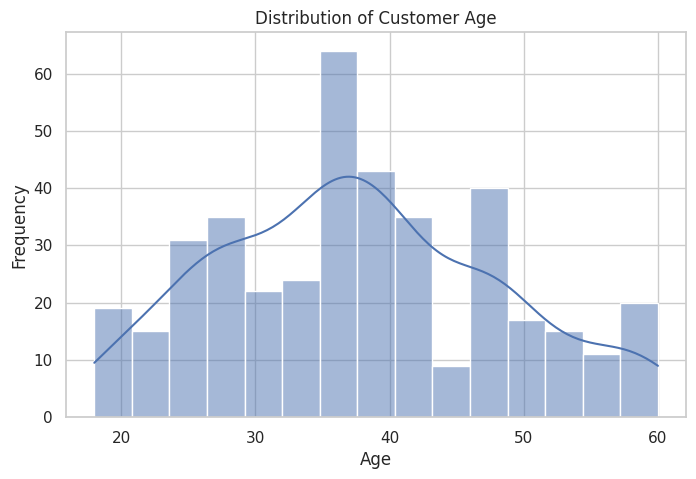

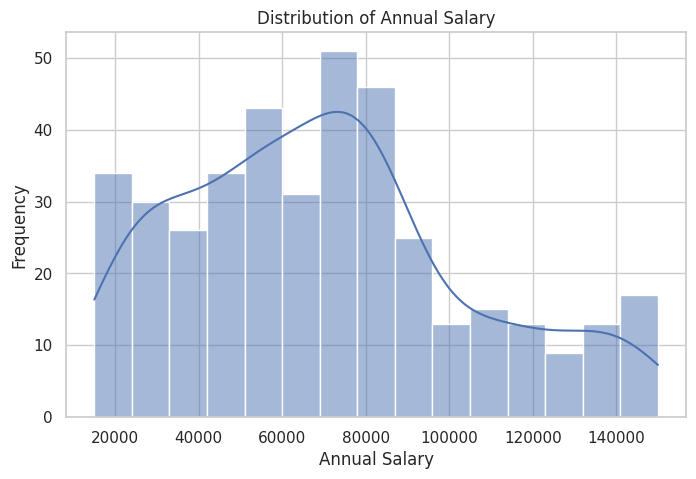

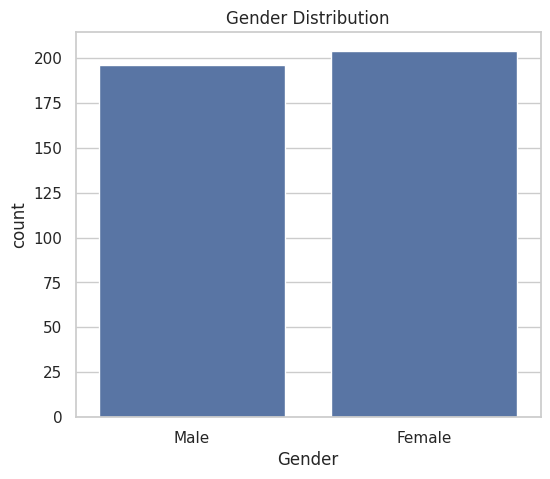

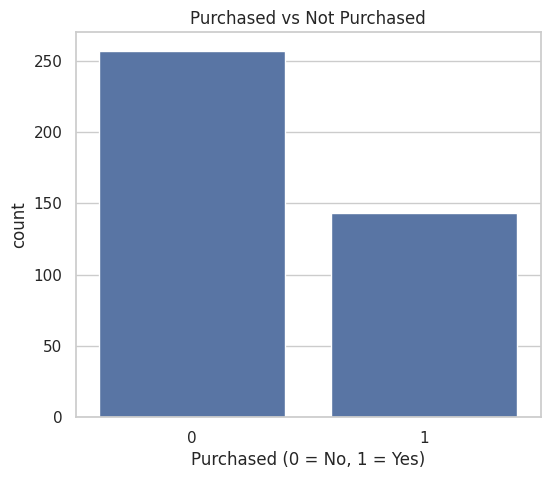

In [16]:
#Q8. Calculate minimum, maximum, mean, and median of Age.
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())
print("Mean Age:", df["Age"].mean())
print("Median Age:", df["Age"].median())


#Q9. Calculate minimum, maximum, mean, and median of Annual Salary.
print("Minimum Salary:", df["EstimatedSalary"].min())
print("Maximum Salary:", df["EstimatedSalary"].max())
print("Mean Salary:", df["EstimatedSalary"].mean())
print("Median Salary:", df["EstimatedSalary"].median())


#Q10. Determine the number of customers who purchased and did not purchase.
print(df["Purchased"].value_counts())


purchase_counts = df["Purchased"].value_counts()

print("Not Purchased:", purchase_counts.get(0, 0))
print("Purchased:", purchase_counts.get(1, 0))


#Q11. Calculate percentage distribution of Male and Female customers.
gender_percentage = df["Gender"].value_counts(normalize=True) * 100

print(gender_percentage)


print(gender_percentage.round(2))


#Q12. Create a histogram for customer ages.
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


#Q13. Create a histogram for Annual Salary.
plt.figure(figsize=(8, 5))

sns.histplot(df["EstimatedSalary"], bins=15, kde=True)

plt.title("Distribution of Annual Salary")
plt.xlabel("Annual Salary")
plt.ylabel("Frequency")

plt.show()


#Q14. Create a count plot showing Gender distribution.
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()


#Q15. Create a count plot showing Purchased vs Not Purchased customers.
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Purchased")
plt.title("Purchased vs Not Purchased")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.show()


SECTION C: DATA PREPROCESSING

In [17]:
#Q18. Check the dataset for missing values.
print(df.isnull().sum())

#Also calculate total missing values:
print("Total Missing Values:", df.isnull().sum().sum())


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Total Missing Values: 0


In [19]:
#Q19. Handle missing values using suitable techniques.
df["Age"] = df["Age"].fillna(df["Age"].median())
df["EstimatedSalary"] = df["EstimatedSalary"].fillna(df["EstimatedSalary"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Purchased"] = df["Purchased"].fillna(df["Purchased"].mode()[0])
print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [84]:
#Q19. Handle missing values using suitable techniques.
#For numerical columns, use the median:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["EstimatedSalary"] = df["EstimatedSalary"].fillna(df["EstimatedSalary"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Purchased"] = df["Purchased"].fillna(df["Purchased"].mode()[0])
print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [22]:
#Q20. Identify duplicate records.
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:", duplicate_count)
#Display duplicates:
print(df[df.duplicated()])

Number of Duplicate Records: 0
Empty DataFrame
Columns: [User ID, Gender, Age, EstimatedSalary, Purchased]
Index: []


In [23]:
#Q21. Remove duplicate records and verify the result.
df = df.drop_duplicates()
print("Duplicate Records After Removal:", df.duplicated().sum())
print("Dataset Shape:", df.shape)

Duplicate Records After Removal: 0
Dataset Shape: (400, 5)


In [51]:
#Q22. Convert Gender into numerical format.
# Using explicit mapping for clarity and robustness
df["Gender"] = df["Gender"].map({"Male": 1,"Female": 0})
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510       1   19            19000          0
1  15810944       1   35            20000          0
2  15668575       0   26            43000          0
3  15603246       0   27            57000          0
4  15804002       1   19            76000          0


In [30]:
#Q23. Verify the dataset after preprocessing.
df.info()
#Check missing values:
print(df.isnull().sum())
#Check duplicates:
print("Duplicates:", df.duplicated().sum())
#Display dataset:
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    int64
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(5)
memory usage: 15.8 KB
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Duplicates: 0
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510       0   19            19000          0
1  15810944       0   35            20000          0
2  15668575       0   26            43000          0
3  15603246       0   27            57000          0
4  15804002       0   19            76000          0


SECTION D: OUTLIER ANALYSIS

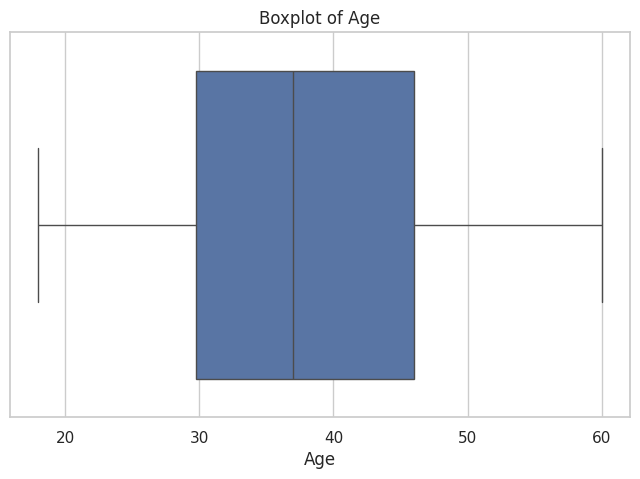

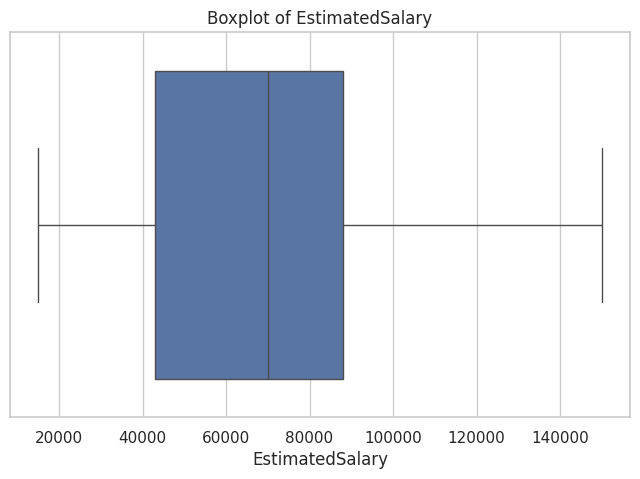

Q1: 29.75
Q3: 46.0
IQR: 16.25
Lower Bound: 5.375
Upper Bound: 70.375
Empty DataFrame
Columns: [User ID, Gender, Age, EstimatedSalary, Purchased]
Index: []
Series([], Name: Age, dtype: int64)
Q1: 43000.0
Q3: 88000.0
IQR: 45000.0
Lower Bound: -24500.0
Upper Bound: 155500.0
Empty DataFrame
Columns: [User ID, Gender, Age, EstimatedSalary, Purchased]
Index: []
Series([], Name: EstimatedSalary, dtype: int64)
Total Age Outliers: 0
Total Salary Outliers: 0


In [33]:
#Q25. Create boxplots for Age and Annual Salary.
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Age"])
plt.title("Boxplot of Age")
plt.show()
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["EstimatedSalary"])
plt.title("Boxplot of EstimatedSalary")
plt.show()

#Q26. Calculate Q1, Q3, and IQR for Age.
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)


#Q27. Determine lower and upper bounds for Age.
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

print("Lower Bound:", lower_bound_age)
print("Upper Bound:", upper_bound_age)


#Q28. Identify all Age outliers.
age_outliers = df[(df["Age"] < lower_bound_age) |(df["Age"] > upper_bound_age)]
print(age_outliers)

#Display only Age values:
print(age_outliers["Age"])
#Q29. Calculate Q1, Q3, and IQR for Annual Salary.
Q1_salary = df["EstimatedSalary"].quantile(0.25)
Q3_salary = df["EstimatedSalary"].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary
print("Q1:", Q1_salary)
print("Q3:", Q3_salary)
print("IQR:", IQR_salary)


#Q30. Determine lower and upper bounds for EstimatedSalary.
lower_bound_salary = Q1_salary - 1.5 * IQR_salary
upper_bound_salary = Q3_salary + 1.5 * IQR_salary

print("Lower Bound:", lower_bound_salary)
print("Upper Bound:", upper_bound_salary)


#Q31. Identify all Salary outliers.
salary_outliers = df[(df["EstimatedSalary"] < lower_bound_salary) |(df["EstimatedSalary"] > upper_bound_salary)]
print(salary_outliers)
#Display salary values:
print(salary_outliers["EstimatedSalary"])
#Q32. Count total outliers in Age and Annual Salary.
age_outlier_count = ((df["Age"] < lower_bound_age) |(df["Age"] > upper_bound_age)).sum()

salary_outlier_count = ((df["EstimatedSalary"] < lower_bound_salary) |(df["EstimatedSalary"] > upper_bound_salary)).sum()
print("Total Age Outliers:", age_outlier_count)
print("Total Salary Outliers:", salary_outlier_count)


In [52]:
#Q33. Remove outliers using IQR method.
df_cleaned = df[(df["Age"] >= lower_bound_age) &(df["Age"] <= upper_bound_age) &(df["EstimatedSalary"] >= lower_bound_salary) &(df["EstimatedSalary"] <= upper_bound_salary)].copy()

print(df_cleaned.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510       1   19            19000          0
1  15810944       1   35            20000          0
2  15668575       0   26            43000          0
3  15603246       0   27            57000          0
4  15804002       1   19            76000          0


In [36]:
#Q34. Compare dataset size before and after outlier removal.
print("Original Dataset Size:", df.shape)
print("Cleaned Dataset Size:", df_cleaned.shape)

print("Rows Removed:", len(df) - len(df_cleaned))


Original Dataset Size: (400, 5)
Cleaned Dataset Size: (400, 5)
Rows Removed: 0


SECTION E: DEEP EDA

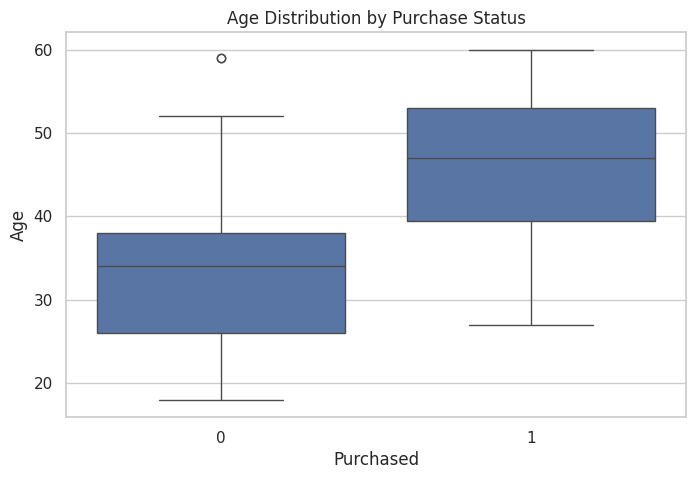

In [37]:
#Q36. Create a boxplot of Age grouped by Purchased status.
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_cleaned, x="Purchased", y="Age")

plt.title("Age Distribution by Purchase Status")

plt.show()


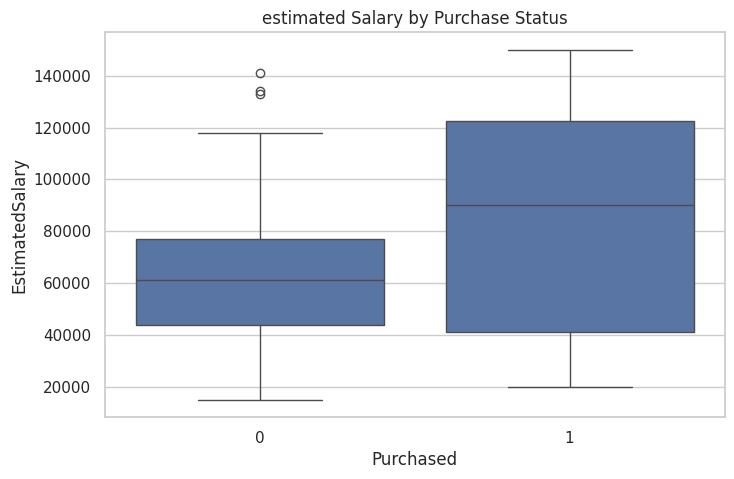

In [40]:
#Q37. Create a boxplot of Annual Salary grouped by Purchased.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Purchased", y="EstimatedSalary")
plt.title("estimated Salary by Purchase Status")
plt.show()

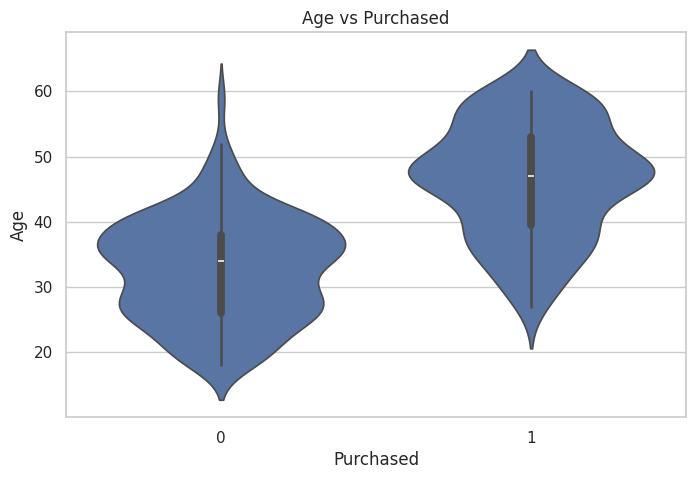

In [42]:
#38. Create a violin plot for Age vs Purchased.
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_cleaned, x="Purchased",y="Age")
plt.title("Age vs Purchased")
plt.show()


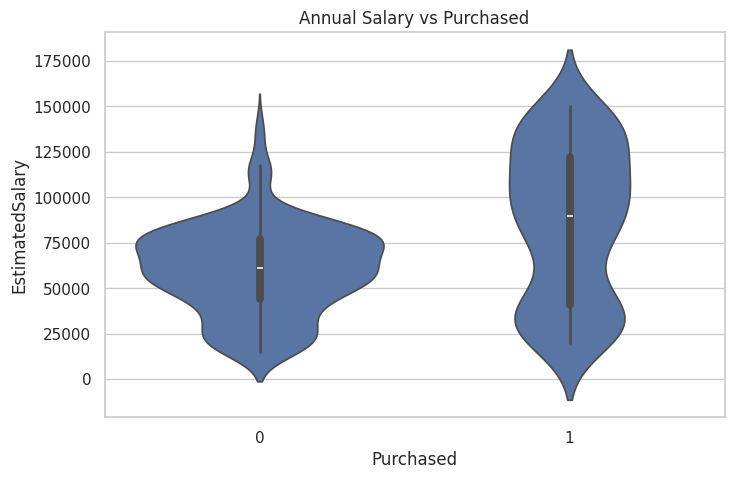

In [44]:
#Q39. Create a violin plot for Annual Salary vs Purchased.
plt.figure(figsize=(8, 5))
sns.violinplot( data=df_cleaned,x="Purchased",y="EstimatedSalary")
plt.title("Annual Salary vs Purchased")
plt.show()

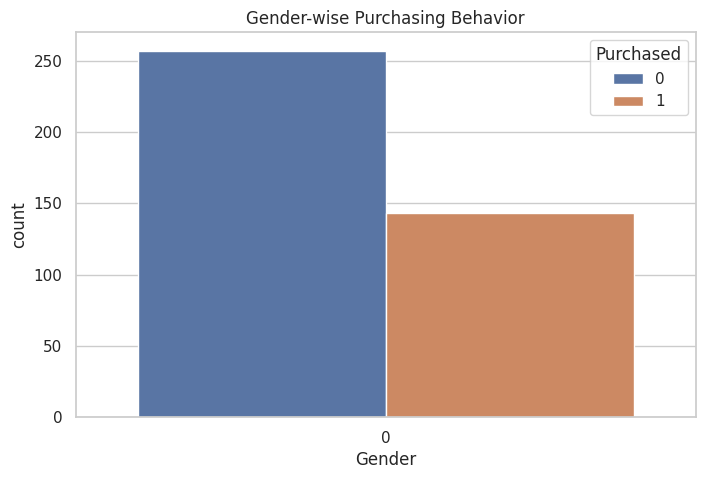

In [45]:
#Q40. Analyze purchasing behavior of Male and Female customers.
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned, x="Gender", hue="Purchased")
plt.title("Gender-wise Purchasing Behavior")
plt.show()

In [54]:
#Q41. Calculate purchase rate for Male customers.
male_customers = df_cleaned[df_cleaned["Gender"] == 1]
print("Male Customers DataFrame (first 5 rows if any):\n", male_customers.head())
print("Number of Male Customers:", len(male_customers))

male_purchase_rate = (male_customers["Purchased"].mean() * 100)

print("Male Purchase Rate:", male_purchase_rate, "%")

Male Customers DataFrame (first 5 rows if any):
     User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510       1   19            19000          0
1  15810944       1   35            20000          0
4  15804002       1   19            76000          0
5  15728773       1   27            58000          0
8  15600575       1   25            33000          0
Number of Male Customers: 196
Male Purchase Rate: 33.6734693877551 %


In [55]:
#Q42. Calculate purchase rate for Female customers.
female_purchase_rate = (df_cleaned[df_cleaned["Gender"] == 0]["Purchased"].mean() * 100)
print("Female Purchase Rate:", female_purchase_rate, "%")


Female Purchase Rate: 37.745098039215684 %


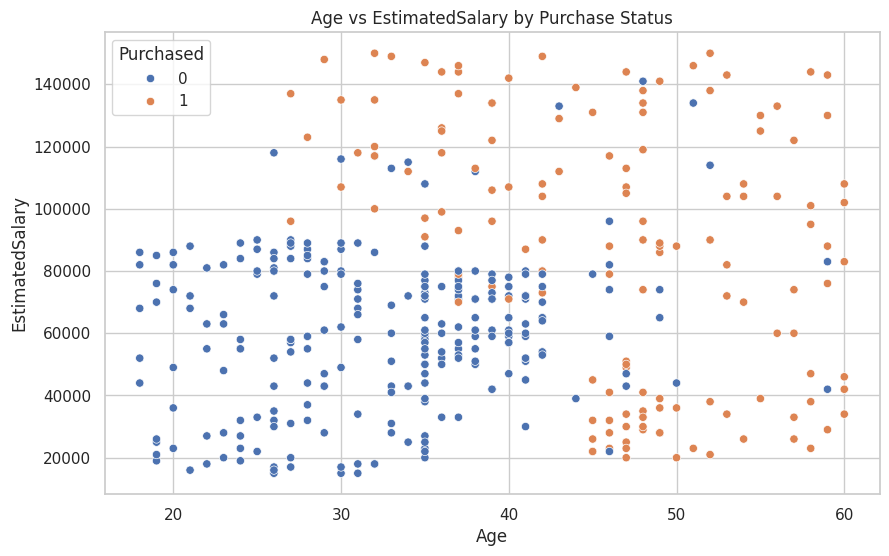

In [57]:
#Q43. Create scatter plot of Age vs Annual Salary colored by Purchased.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned,x="Age",y="EstimatedSalary",hue="Purchased")
plt.title("Age vs EstimatedSalary by Purchase Status")
plt.show()


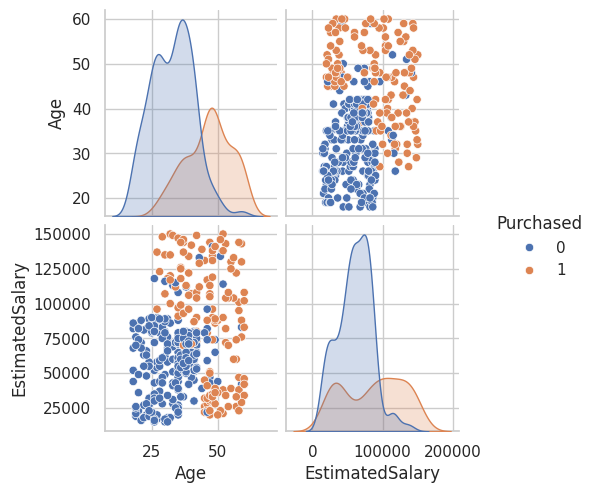

                  User ID    Gender       Age  EstimatedSalary  Purchased
User ID          1.000000 -0.025249 -0.000721         0.071097   0.007120
Gender          -0.025249  1.000000 -0.073741        -0.060435  -0.042469
Age             -0.000721 -0.073741  1.000000         0.155238   0.622454
EstimatedSalary  0.071097 -0.060435  0.155238         1.000000   0.362083
Purchased        0.007120 -0.042469  0.622454         0.362083   1.000000


In [59]:
#Q45. Generate a pair plot for numerical features.
sns.pairplot(df_cleaned[ ["Age", "EstimatedSalary", "Purchased"]], hue="Purchased")
plt.show()
#Q46. Create a correlation matrix.
correlation_matrix = df_cleaned.corr(numeric_only=True)
print(correlation_matrix)


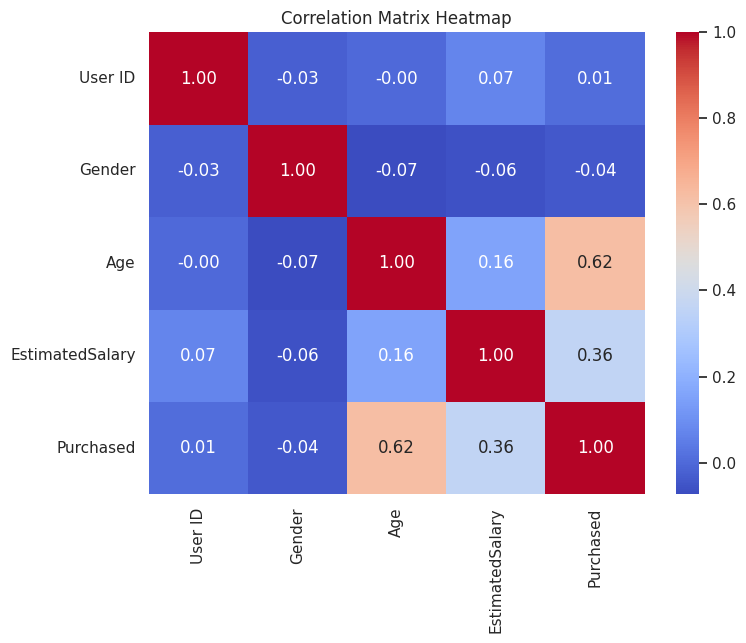

In [60]:
#Q47. Visualize the correlation matrix using a heatmap.
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


In [61]:
#Q48. Identify attributes most strongly correlated with Purchased.
purchase_correlation = correlation_matrix["Purchased"].sort_values(ascending=False)

print(purchase_correlation)
print(correlation_matrix["Purchased"].drop("Purchased").sort_values(key=abs, ascending=False))


Purchased          1.000000
Age                0.622454
EstimatedSalary    0.362083
User ID            0.007120
Gender            -0.042469
Name: Purchased, dtype: float64
Age                0.622454
EstimatedSalary    0.362083
Gender            -0.042469
User ID            0.007120
Name: Purchased, dtype: float64


In [64]:
#Q49. Determine whether Age or Annual Salary has stronger influence.
age_corr = abs(correlation_matrix.loc["Age", "Purchased"])
salary_corr = abs(correlation_matrix.loc["EstimatedSalary", "Purchased"])
print("Age Correlation:", age_corr)
print("Salary Correlation:", salary_corr)
if age_corr > salary_corr:
    print("Age has a stronger influence on purchase decisions.")
else:
    print("EstimatedSalary has a stronger influence on purchase decisions.")


Age Correlation: 0.6224541988845287
Salary Correlation: 0.36208302580467777
Age has a stronger influence on purchase decisions.


Age Group Analysis
Young      5.660377
Adult     26.344086
Senior    85.436893
Elder           NaN
Name: Purchased, dtype: float64


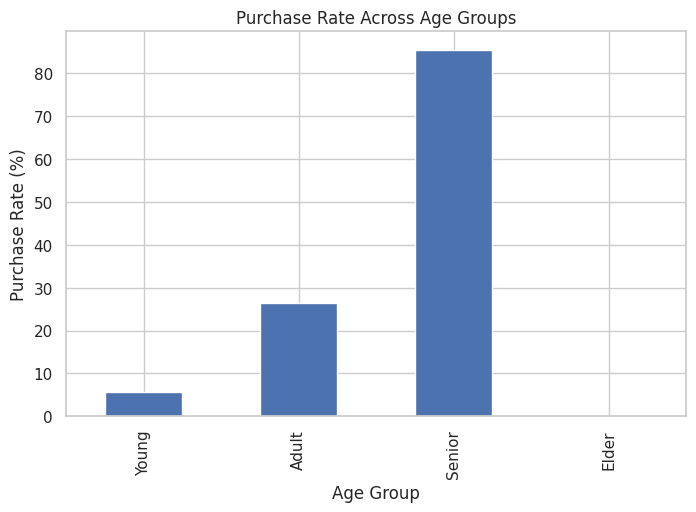

In [65]:
#Q50. Analyze purchasing patterns across different age groups.

age_bins = [18, 30, 45, 60, 100]

age_labels = ["Young","Adult","Senior","Elder"]

df_cleaned["Age Group Analysis"] = pd.cut(df_cleaned["Age"],bins=age_bins,labels=age_labels)

#Calculate purchase rate:
age_purchase_pattern = df_cleaned.groupby("Age Group Analysis",observed=False)["Purchased"].mean() * 100
print(age_purchase_pattern)
#Visualize:
age_purchase_pattern.plot(kind="bar", figsize=(8, 5))
plt.title("Purchase Rate Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Purchase Rate (%)")
plt.show()


SECTION F: FEATURE ENGINEERING


In [68]:
#Q51. Create Salary_Age_Ratio.
df_cleaned["Salary_Age_Ratio"] = (df_cleaned["EstimatedSalary"] /df_cleaned["Age"])

print(df_cleaned[["Age", "EstimatedSalary", "Salary_Age_Ratio"]].head())



   Age  EstimatedSalary  Salary_Age_Ratio
0   19            19000       1000.000000
1   35            20000        571.428571
2   26            43000       1653.846154
3   27            57000       2111.111111
4   19            76000       4000.000000


In [69]:
#Q53. Create Age Group categories.
df_cleaned["Age_Group"] = pd.cut(df_cleaned["Age"], bins=[17, 30, 45, 60],labels=["Young", "Adult", "Senior"])
print(df_cleaned[["Age", "Age_Group"]].head())


   Age Age_Group
0   19     Young
1   35     Adult
2   26     Young
3   27     Young
4   19     Young


In [70]:
#Q54. Encode Age Group into numerical format.
df_cleaned["Age_Group_Encoded"] = df_cleaned["Age_Group"].map({"Young": 0,"Adult": 1,"Senior": 2})


In [71]:
df_cleaned["Age_Group_Encoded"] = (df_cleaned["Age_Group"].cat.codes)



In [74]:
#Q55. Create Salary Categories.
#The categories can be created based on quantiles.
df_cleaned["Salary_Category"] = pd.qcut(df_cleaned["EstimatedSalary"],q=3,labels=["Low Income","Middle Income","High Income"])

print(df_cleaned[["EstimatedSalary", "Salary_Category"]].head())


   EstimatedSalary Salary_Category
0            19000      Low Income
1            20000      Low Income
2            43000      Low Income
3            57000   Middle Income
4            76000   Middle Income


In [75]:
#Q56. Encode Salary Categories.
df_cleaned["Salary_Category_Encoded"] = (df_cleaned["Salary_Category"].cat.codes)


In [77]:
#Q57. Create Customer Segment based on salary and purchase behavior.
def customer_segment(row):

    if row["Purchased"] == 1 and row["Salary_Category"] == "High Income":
        return "Premium Buyer"

    elif row["Purchased"] == 1:
        return "Potential Buyer"

    elif row["Salary_Category"] == "High Income":
        return "High Income Non-Buyer"

    else:
        return "Low Potential Customer"


df_cleaned["Customer_Segment"] = df_cleaned.apply(customer_segment,axis=1)

print(df_cleaned[["EstimatedSalary","Purchased","Customer_Segment"]].head())



   EstimatedSalary  Purchased        Customer_Segment
0            19000          0  Low Potential Customer
1            20000          0  Low Potential Customer
2            43000          0  Low Potential Customer
3            57000          0  Low Potential Customer
4            76000          0  Low Potential Customer


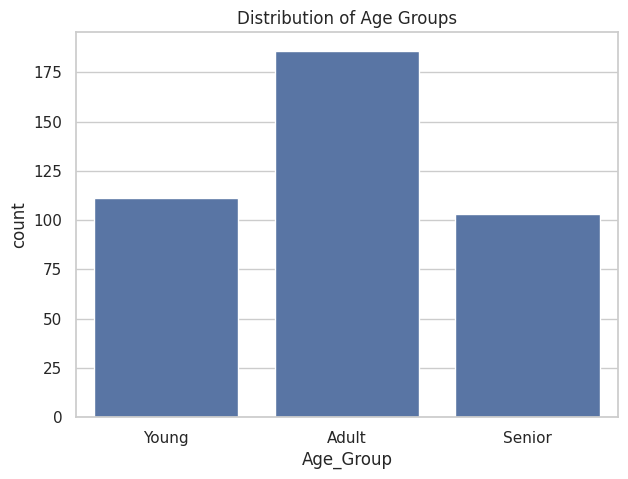

In [78]:
#Q58. Visualize distribution of Age Groups.
plt.figure(figsize=(7, 5))

sns.countplot(data=df_cleaned,x="Age_Group")

plt.title("Distribution of Age Groups")

plt.show()


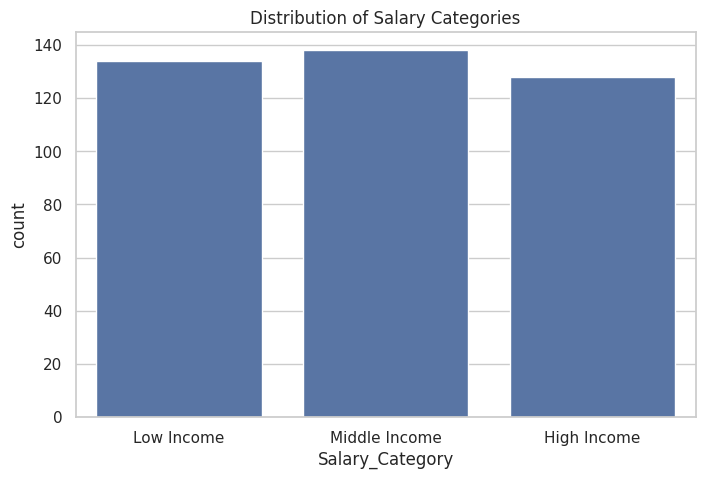

In [79]:
#Q59. Visualize distribution of Salary Categories.
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned,x="Salary_Category")
plt.title("Distribution of Salary Categories")
plt.show()


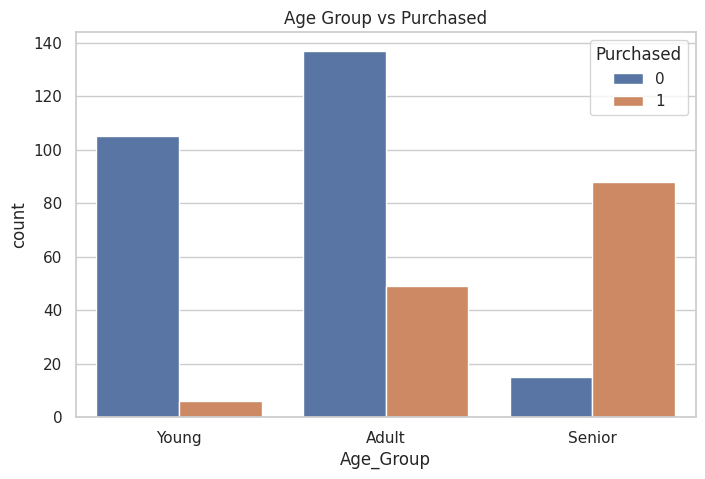

Age_Group
Young      5.405405
Adult     26.344086
Senior    85.436893
Name: Purchased, dtype: float64


In [80]:
#Q60. Analyze relationship between Age Groups and Purchased.
plt.figure(figsize=(8, 5))

sns.countplot(data=df_cleaned,x="Age_Group",hue="Purchased")
plt.title("Age Group vs Purchased")
plt.show()
#Purchase rate calculation:
age_group_purchase = df_cleaned.groupby("Age_Group",observed=False)["Purchased"].mean() * 100
print(age_group_purchase)

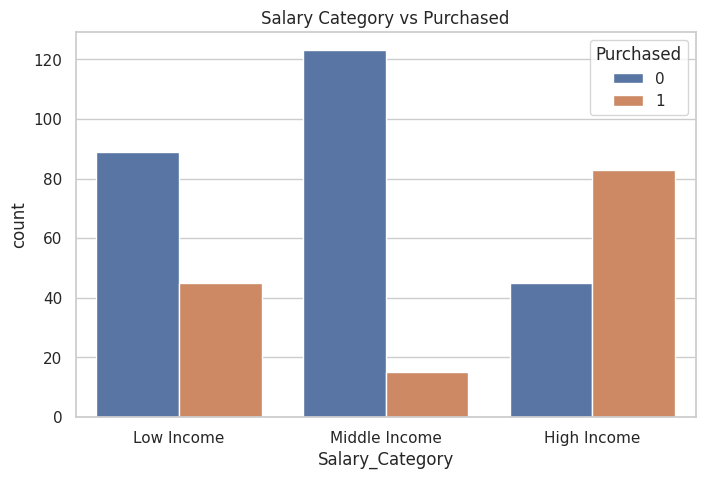

Salary_Category
Low Income       33.582090
Middle Income    10.869565
High Income      64.843750
Name: Purchased, dtype: float64
Original Columns:
['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']
Feature Engineered Columns:
['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased', 'Age Group Analysis', 'Salary_Age_Ratio', 'Age_Group', 'Age_Group_Encoded', 'Salary_Category', 'Salary_Category_Encoded', 'Customer_Segment']
Original Shape: (400, 5)
Feature Engineered Shape: (400, 12)


In [81]:
#Q61. Analyze relationship between Salary Categories and Purchased.
plt.figure(figsize=(8, 5))

sns.countplot(data=df_cleaned,x="Salary_Category",hue="Purchased")

plt.title("Salary Category vs Purchased")

plt.show()

#Calculate purchase rate:
salary_category_purchase = df_cleaned.groupby("Salary_Category", observed=False)["Purchased"].mean() * 100
print(salary_category_purchase)

#Q62. Compare original dataset with feature-engineered dataset.
#Original dataset:
print("Original Columns:")
print(df.columns.tolist())

#Feature-engineered dataset:
print("Feature Engineered Columns:")
print(df_cleaned.columns.tolist())

#Compare shapes:
print("Original Shape:", df.shape)
print("Feature Engineered Shape:", df_cleaned.shape)



In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load Dataset
df = pd.read_csv("carpurchase.csv")

# Dataset Information
print(df.head(10))
print(df.tail(10))
print(df.shape)
print(df.dtypes)
print(df.describe())
df.info()

# Missing Values
print(df.isnull().sum())

# Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["EstimatedSalary"] = df["EstimatedSalary"].fillna(
    df["EstimatedSalary"].median()
)

df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

# Remove Duplicates
df = df.drop_duplicates()

# Encode Gender
df["Gender"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

# Age Outlier Calculation
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

# Salary Outlier Calculation
Q1_salary = df["EstimatedSalary"].quantile(0.25)
Q3_salary = df["EstimatedSalary"].quantile(0.75)

IQR_salary = Q3_salary - Q1_salary

lower_salary = Q1_salary - 1.5 * IQR_salary
upper_salary = Q3_salary + 1.5 * IQR_salary

# Remove Outliers
df_cleaned = df[
    (df["Age"] >= lower_age) &
    (df["Age"] <= upper_age) &
    (df["EstimatedSalary"] >= lower_salary) &
    (df["EstimatedSalary"] <= upper_salary)
].copy()

# Feature Engineering
df_cleaned["Salary_Age_Ratio"] = (
    df_cleaned["EstimatedSalary"] /
    df_cleaned["Age"]
)

df_cleaned["Age_Group"] = pd.cut(
    df_cleaned["Age"],
    bins=[17, 30, 45, 60],
    labels=["Young", "Adult", "Senior"]
)

df_cleaned["Age_Group_Encoded"] = (
    df_cleaned["Age_Group"].cat.codes
)

df_cleaned["Salary_Category"] = pd.qcut(
    df_cleaned["EstimatedSalary"],
    q=3,
    labels=[
        "Low Income",
        "Middle Income",
        "High Income"
    ]
)

df_cleaned["Salary_Category_Encoded"] = (
    df_cleaned["Salary_Category"].cat.codes
)

# Customer Segmentation
def customer_segment(row):

    if (
        row["Purchased"] == 1 and
        row["Salary_Category"] == "High Income"
    ):
        return "Premium Buyer"

    elif row["Purchased"] == 1:
        return "Potential Buyer"

    elif row["Salary_Category"] == "High Income":
        return "High Income Non-Buyer"

    else:
        return "Low Potential Customer"


df_cleaned["Customer_Segment"] = df_cleaned.apply(
    customer_segment,
    axis=1
)

# Save Final Dataset
df_cleaned.to_csv(
    "car_purchase_cleaned_feature_engineered.csv",
    index=False
)

print("Analysis Completed Successfully!")
print(df_cleaned.head())



    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
5  15728773    Male   27            58000          0
6  15598044  Female   27            84000          0
7  15694829  Female   32           150000          1
8  15600575    Male   25            33000          0
9  15727311  Female   35            65000          0
      User ID  Gender  Age  EstimatedSalary  Purchased
390  15807837    Male   48            33000          1
391  15592570    Male   47            23000          1
392  15748589  Female   45            45000          1
393  15635893    Male   60            42000          1
394  15757632  Female   39            59000          0
395  15691863  Female   46            41000          1
396  15706071    Male   51      